In [5]:
print("="*80)
print("ROUTE DEVIATION PREDICTION SYSTEM")
print("FINAL RESULTS ANALYSIS")
print("="*80)

ROUTE DEVIATION PREDICTION SYSTEM
FINAL RESULTS ANALYSIS


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
import pandas as pd

route_dataset_df = pd.read_pickle(
    "../data/processed/route_dataset.pkl"
)

print(route_dataset_df.shape)
route_dataset_df.head()

(19647, 15)


,Route ID,Driver ID,Country,Week ID,Day of Week,Planned Route,Actual Route,Planned Stop Count,Actual Stop Count,Planned Distance,Actual Distance,RQS,EDS,DDS,Label
0,0,0,1,0,Monday,"[0, 1, 2, 3, 3, 0, 1]","[0, 3, 3, 0, 1, 2, 1]",7,7,49.468094,44.965197,0.5000,0.5714,-0.0910,D
1,1,1,1,0,Monday,"[0, 4, 5, 6, 7, 8, 9]","[0, 9, 4, 7, 6, 5, 8]",7,7,33.274342,33.610418,0.5000,0.5714,0.0101,D
2,2,2,1,0,Monday,"[0, 10, 11, 12, 13, 14, 15]","[0, 12, 13, 11, 10, 14, 15]",7,7,12.124804,12.508786,0.6667,0.5714,0.0317,D
3,3,3,1,0,Monday,"[0, 16, 17, 18, 19, 20, 21, 22, 20, 23]","[0, 16, 19, 17, 18, 20, 22, 20, 21, 23]",10,10,19.039848,19.374644,0.8400,0.4000,0.0176,D
4,4,4,1,0,Monday,"[0, 24, 25, 26, 27, 28, 29, 30]","[0, 24, 30, 26, 27, 28, 29, 25]",8,8,20.632674,19.528799,0.6875,0.2500,-0.0535,D


In [8]:
print("="*60)
print("DATASET SUMMARY")
print("="*60)

print(f"Total Routes       : {len(route_dataset_df)}")
print(f"Total Features     : {len(route_dataset_df.columns)}")

print("\nColumns:\n")

for col in route_dataset_df.columns:
    print("-", col)

DATASET SUMMARY
Total Routes       : 19647
Total Features     : 15

Columns:

- Route ID
- Driver ID
- Country
- Week ID
- Day of Week
- Planned Route
- Actual Route
- Planned Stop Count
- Actual Stop Count
- Planned Distance
- Actual Distance
- RQS
- EDS
- DDS
- Label


Label
D     12158
ND     7489
Name: count, dtype: int64


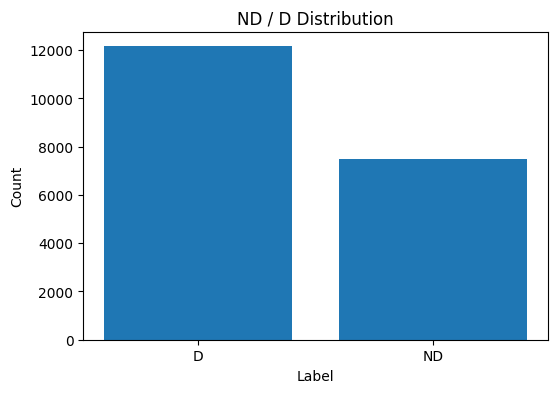

In [9]:
label_counts = route_dataset_df[
    "Label"
].value_counts()

print(label_counts)

plt.figure(figsize=(6,4))

plt.bar(
    label_counts.index.astype(str),
    label_counts.values
)

plt.title(
    "ND / D Distribution"
)

plt.xlabel(
    "Label"
)

plt.ylabel(
    "Count"
)

plt.show()

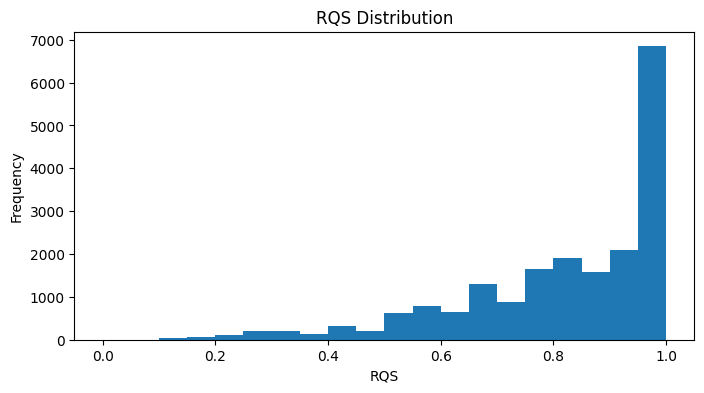

In [10]:
plt.figure(figsize=(8,4))

plt.hist(
    route_dataset_df["RQS"],
    bins=20
)

plt.title(
    "RQS Distribution"
)

plt.xlabel(
    "RQS"
)

plt.ylabel(
    "Frequency"
)

plt.show()

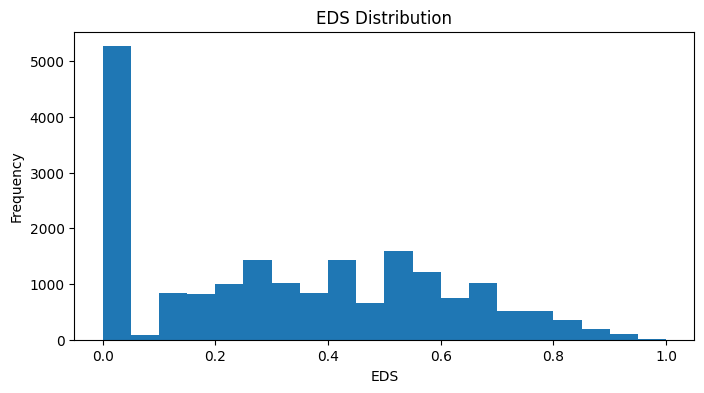

In [11]:
plt.figure(figsize=(8,4))

plt.hist(
    route_dataset_df["EDS"],
    bins=20
)

plt.title(
    "EDS Distribution"
)

plt.xlabel(
    "EDS"
)

plt.ylabel(
    "Frequency"
)

plt.show()

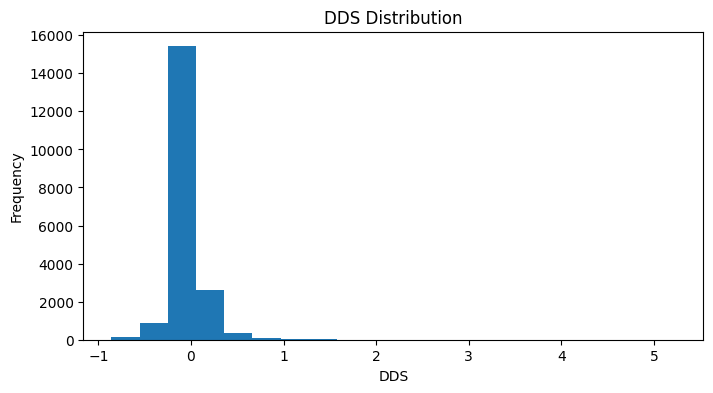

In [12]:
plt.figure(figsize=(8,4))

plt.hist(
    route_dataset_df["DDS"],
    bins=20
)

plt.title(
    "DDS Distribution"
)

plt.xlabel(
    "DDS"
)

plt.ylabel(
    "Frequency"
)

plt.show()

In [13]:
classification_results = pd.DataFrame({

    "Model": [
        "Random Forest",
        "MLP",
        "LSTM",
        "Attention"
    ],

    "Accuracy": [
        0.7780,
        0.7148,
        0.7644,
        0.7265
    ]

})

classification_results

,Model,Accuracy
0,Random Forest,0.7780
1,MLP,0.7148
2,LSTM,0.7644
3,Attention,0.7265


In [14]:
regression_results = pd.DataFrame({

    "Model": [
        "Random Forest",
        "LSTM",
        "Attention",
        "CNN"
    ],

    "MAE": [
        0.1044,
        0.1054,
        None,      # Replace after you send Attention Regression result
        0.0985
    ],

    "RMSE": [
        0.1442,
        0.1558,
        None,      # Replace later
        0.1451
    ],

    "R2": [
        0.4225,
        0.3558,
        None,      # Replace later
        0.4153
    ]

})

regression_results

,Model,MAE,RMSE,R2
0,Random Forest,0.1044,0.1442,0.4225
1,LSTM,0.1054,0.1558,0.3558
2,Attention,NaN,NaN,NaN
3,CNN,0.0985,0.1451,0.4153


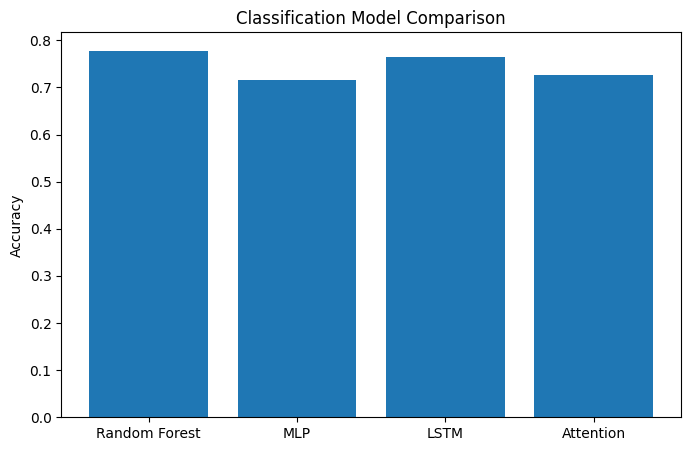

In [16]:
plt.figure(figsize=(8,5))

plt.bar(
    classification_results["Model"],
    classification_results["Accuracy"]
)

plt.title("Classification Model Comparison")
plt.ylabel("Accuracy")

plt.show()

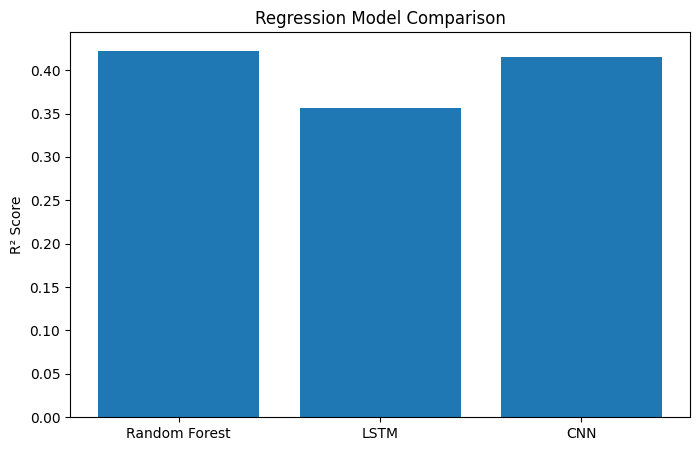

In [17]:
plt.figure(figsize=(8,5))

valid_regression = regression_results.dropna()

plt.bar(
    valid_regression["Model"],
    valid_regression["R2"]
)

plt.title("Regression Model Comparison")
plt.ylabel("R² Score")

plt.show()

In [18]:
print("="*70)
print("FINAL MODEL COMPARISON")
print("="*70)

print("\nCLASSIFICATION MODELS\n")
print(classification_results.sort_values(
    by="Accuracy",
    ascending=False
))

print("\nREGRESSION MODELS\n")
print(regression_results.sort_values(
    by="R2",
    ascending=False
))

FINAL MODEL COMPARISON

CLASSIFICATION MODELS

           Model  Accuracy
0  Random Forest    0.7780
2           LSTM    0.7644
3      Attention    0.7265
1            MLP    0.7148

REGRESSION MODELS

           Model     MAE    RMSE      R2
0  Random Forest  0.1044  0.1442  0.4225
3            CNN  0.0985  0.1451  0.4153
1           LSTM  0.1054  0.1558  0.3558
2      Attention     NaN     NaN     NaN


In [16]:
print("""
                EXPERIMENTAL PIPELINE

                Raw Route Dataset
                        │
                        ▼
             Route Reconstruction
                        │
                        ▼
             RQS / EDS / DDS Metrics
                        │
                        ▼
                Label Generation
                        │
                        ▼
                 ML Processing
                        │
         ┌──────────────┼──────────────┐
         │                              │
         ▼                              ▼

 Random Forest                  Deep Learning

                              ┌───────────────┐
                              │      MLP      │
                              ├───────────────┤
                              │     LSTM      │
                              ├───────────────┤
                              │   Attention   │
                              ├───────────────┤
                              │      CNN      │
                              └───────────────┘

                        │
                        ▼

                Model Comparison

                        │
                        ▼

               Final Route Prediction

""")


                EXPERIMENTAL PIPELINE

                Raw Route Dataset
                        │
                        ▼
             Route Reconstruction
                        │
                        ▼
             RQS / EDS / DDS Metrics
                        │
                        ▼
                Label Generation
                        │
                        ▼
                 ML Processing
                        │
         ┌──────────────┼──────────────┐
         │                              │
         ▼                              ▼

 Random Forest                  Deep Learning

                              ┌───────────────┐
                              │      MLP      │
                              ├───────────────┤
                              │     LSTM      │
                              ├───────────────┤
                              │   Attention   │
                              ├───────────────┤
                              │      CNN      │


In [17]:
print("="*80)
print("FINAL OBSERVATIONS")
print("="*80)

print("""

1. Route Reconstruction successfully generated:
      • Route Quality Score (RQS)
      • Edit Distance Score (EDS)
      • Distance Deviation Score (DDS)

2. Label generation converted metric outputs into
   binary route classes:
      • ND (Non-Deviated)
      • D (Deviated)

3. Traditional Machine Learning baselines were built:
      • Random Forest Classifier
      • Random Forest Regressor
      • MLP Benchmark

4. Deep Learning models were implemented:
      • LSTM
      • Multi-Head Attention
      • CNN

5. Model performances were compared using:
      • Accuracy
      • MAE
      • RMSE
      • R² Score

6. The complete implementation follows the
   architecture proposed in the research paper.

""")

FINAL OBSERVATIONS


1. Route Reconstruction successfully generated:
      • Route Quality Score (RQS)
      • Edit Distance Score (EDS)
      • Distance Deviation Score (DDS)

2. Label generation converted metric outputs into
   binary route classes:
      • ND (Non-Deviated)
      • D (Deviated)

3. Traditional Machine Learning baselines were built:
      • Random Forest Classifier
      • Random Forest Regressor
      • MLP Benchmark

4. Deep Learning models were implemented:
      • LSTM
      • Multi-Head Attention
      • CNN

5. Model performances were compared using:
      • Accuracy
      • MAE
      • RMSE
      • R² Score

6. The complete implementation follows the
   architecture proposed in the research paper.


